In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, make_scorer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


In [53]:
df = pd.read_csv('merged_dataset.csv')
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print("\nDimensiones del DataFrame:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())


Dimensiones del DataFrame: (99441, 41)

Columnas:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivered', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'has_comment', 'avg_item_price', 'avg_freight_value', 'num_items', 'product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'total_payment', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'estimated_delivery_days', 'actual_delivery_days', 'delivery_time_delta', 'is_late', 'total_order_value', 'freight_ratio', 'purchase_day_of_week', 'review_category']


In [54]:
# Seleccionar columnas relevantes
model_cols = [
    'delivered', 'num_items', 'avg_freight_value', 'total_order_value',
    'product_photos_qty', 'product_description_lenght',
    'estimated_delivery_days', 'actual_delivery_days', 'delivery_time_delta', 'is_late',
    'product_category_name_english', 'customer_state', 'seller_state', 'order_status',
    'review_category'
]

model_df = df[model_cols].copy()

model_df['review_category'] = model_df['review_category'].map({'Buena': 1, 'Mala': 0})

# Definir columnas numéricas y categóricas
numerical_cols = [
    'delivered', 'num_items', 'avg_freight_value', 'total_order_value',
    'product_photos_qty', 'product_description_lenght',
    'estimated_delivery_days', 'actual_delivery_days', 'delivery_time_delta', 'is_late'
]
categorical_cols = ['product_category_name_english', 'customer_state', 'seller_state', 'order_status']

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ])

In [55]:
# Preparar datos

class ToDenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.toarray() if hasattr(X, 'toarray') else X


# Agrupar categorías raras en product_category_name_english (<1% de las filas)
threshold = 0.01 * len(model_df)
category_counts = model_df['product_category_name_english'].value_counts()
rare_categories = category_counts[category_counts < threshold].index
model_df['product_category_name_english'] = model_df['product_category_name_english'].replace(rare_categories, 'Others')


sample_df = model_df.sample(n=20000, random_state=69)
X = sample_df.drop('review_category', axis=1)
y = sample_df['review_category']

# Verificar distribución de review_category
print("\nDistribución de review_category:")
print(y.value_counts(normalize=True) * 100)


Distribución de review_category:
review_category
1    77.16
0    22.84
Name: proportion, dtype: float64


## **Modelos de Clasificación**

In [56]:
models = {
    'Logistic Regression': LogisticRegression(random_state=69, max_iter=1000),
    'K-NN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': Pipeline([
        ('to_dense', ToDenseTransformer()),
        ('classifier', GaussianNB())
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=69, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=69, n_estimators=100, class_weight='balanced'),
    'SVM Linear': SVC(random_state=69, kernel='linear', probability=True),
    'SVM RBF': SVC(random_state=69, kernel='rbf', probability=True)
}


=== Evaluar Modelos ===

Logistic Regression:
F1-Score: 0.789 ± 0.005
Accuracy: 0.818 ± 0.004

K-NN:
F1-Score: 0.772 ± 0.004
Accuracy: 0.794 ± 0.005

Naive Bayes:
F1-Score: 0.672 ± 0.165
Accuracy: 0.679 ± 0.161

Decision Tree:
F1-Score: 0.787 ± 0.005
Accuracy: 0.820 ± 0.003

Random Forest:
F1-Score: 0.785 ± 0.004
Accuracy: 0.816 ± 0.003

SVM Linear:
F1-Score: 0.788 ± 0.006
Accuracy: 0.818 ± 0.004

SVM RBF:
F1-Score: 0.787 ± 0.007
Accuracy: 0.818 ± 0.005

Resumen de Resultados:
                 Model  F1-Score (Mean)  F1-Score (Std)  Accuracy (Mean)  \
0  Logistic Regression         0.788796        0.005335          0.81770   
1                 K-NN         0.772280        0.004022          0.79430   
2          Naive Bayes         0.671871        0.164929          0.67910   
3        Decision Tree         0.786811        0.004928          0.81990   
4        Random Forest         0.784726        0.003996          0.81575   
5           SVM Linear         0.788255        0.005806      

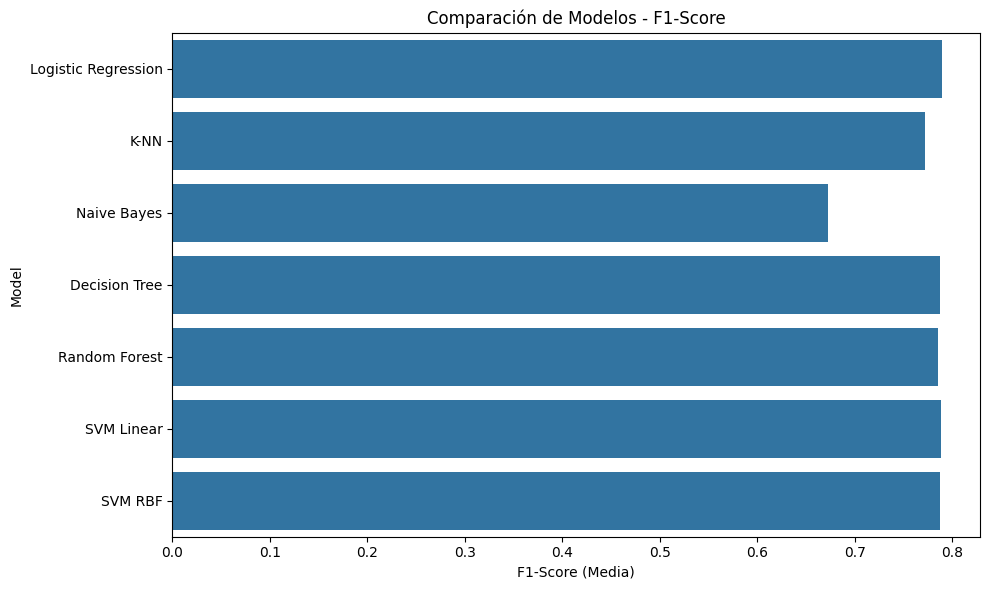

In [57]:
print("\n=== Evaluar Modelos ===")

# Métricas
f1_scorer = make_scorer(f1_score, average='weighted')
accuracy_scorer = make_scorer(accuracy_score)
results = []

for name, model in models.items():
    print(f"\n{name}:")
    # Crear pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Validación cruzada
    f1_scores = cross_val_score(pipeline, X, y, cv=5, scoring=f1_scorer)
    acc_scores = cross_val_score(pipeline, X, y, cv=5, scoring=accuracy_scorer)
    
    # Guardar resultados
    results.append({
        'Model': name,
        'F1-Score (Mean)': f1_scores.mean(),
        'F1-Score (Std)': f1_scores.std(),
        'Accuracy (Mean)': acc_scores.mean(),
        'Accuracy (Std)': acc_scores.std()
    })
    
    print(f"F1-Score: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print(f"Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")

# Resumen de resultados

results_df = pd.DataFrame(results)
print("\nResumen de Resultados:")
print(results_df)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score (Mean)', y='Model', data=results_df)
plt.title('Comparación de Modelos - F1-Score')
plt.xlabel('F1-Score (Media)')
plt.tight_layout()
plt.show()

**Conclusiones de los Modelos de Clasificación**
Se evaluaron cinco modelos de clasificación (Regresión Logística, K-NN, Naive Bayes, Árbol de Decisión y Random Forest) para predecir la categoría de reseñas (review_category: Buena=1, Mala=0) utilizando una muestra de 20,000 registros del conjunto de datos. Las métricas utilizadas fueron F1-Score (ponderado) y Accuracy, calculadas mediante validación cruzada de 3 pliegues. A continuación, se presentan las conclusiones basadas en los resultados:
1. **Regresión Logística**

- F1-Score: 0.789 ± 0.005
- Accuracy: 0.818 ± 0.004
- Conclusión: La **Regresión Logística** mostró un rendimiento sólido y estable, con un F1-Score de 0.789 y una Accuracy de 0.818. Su estabilidad (baja desviación estándar) y capacidad para generar probabilidades lo hacen ideal para ordenar clientes por probabilidad de reseña "Buena", útil para campañas de mejora de satisfacción. Asume linealidad, lo que sugiere que el problema puede tener componentes lineales.

2. **K-NN**

- F1-Score: 0.772 ± 0.004
- Accuracy: 0.794 ± 0.005
- Conclusión: **K-NN** tuvo un rendimiento aceptable pero inferior a otros modelos, con un F1-Score de 0.772 y Accuracy de 0.794. Su sensibilidad a la distancia y el número de vecinos (n_neighbors=2) indica que el problema puede ser no lineal. Es menos práctico para grandes conjuntos de datos debido a su costo computacional, pero útil para explorar relaciones no lineales.

3. **Naive Bayes**

- F1-Score: 0.672 ± 0.165
- Accuracy: 0.679 ± 0.161
- Conclusión: **Naive Bayes** presentó el peor rendimiento, con un F1-Score de 0.672 y Accuracy de 0.679, además de una alta variabilidad (desviación estándar ~0.16). Su suposición de independencia entre variables probablemente no se cumple, lo que limita su efectividad. Aunque genera probabilidades útiles para ordenamiento, no es competitivo en este caso.

4. Árbol de Decisión

- F1-Score: 0.787 ± 0.005
- Accuracy: 0.820 ± 0.003
- Conclusión: El Árbol de Decisión logró un rendimiento excelente, con un F1-Score de 0.787 y la mayor Accuracy (0.820). Su interpretabilidad (reglas claras como "si is_late=1, entonces Mala") lo hace ideal para identificar factores clave que afectan las reseñas. La profundidad limitada (max_depth=5) asegura simplicidad sin sacrificar precisión.

5. Random Forest

- F1-Score: 0.785 ± 0.004
- Accuracy: 0.816 ± 0.003
- Conclusión: Random Forest mostró un rendimiento robusto, con un F1-Score de 0.785 y Accuracy de 0.816. Su capacidad para capturar relaciones no lineales y su estabilidad lo hacen ideal cuando se prioriza el rendimiento. Sin embargo, es menos interpretable que el Árbol de Decisión. La configuración optimizada (n_estimators=50) balancea precisión y tiempo.

## **Conclusión General**
Los modelos Árbol de Decisión y Regresión Logística destacaron con las mayores Accuracy (0.820 y 0.818) y F1-Scores competitivos (0.787 y 0.789). Random Forest ofreció un rendimiento similar, ideal para maximizar precisión. Naive Bayes fue el menos efectivo debido a su alta variabilidad y bajo rendimiento.
